In [103]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sns.set_theme()

In [104]:
df = pd.read_csv("/content/SwordLevelMaster edit.csv")

In [105]:
df = df.drop('Unnamed: 3', axis =1)

In [106]:
df['Level'] = df['Level'].apply(lambda x: int(x.strip('\'')))
df['Exp'] = df['Exp'].apply(lambda x: int(x.strip('\'')))

In [107]:
df = df.rename(columns={"Level": "Lv.", "Exp": "Cumulative EXP"})

In [108]:
r, c = df.shape

In [109]:
test = []
for i in range(r):
  cur_exp = df['Cumulative EXP'][i]
  if i == r-1:
    next_exp = 0
  else:
    next_exp = df['Cumulative EXP'][i+1]
  if cur_exp == 0 or next_exp == 0:
    test.append(next_exp)
  else:
    test.append(next_exp - cur_exp)
df["EXP until Next Lv."] = test

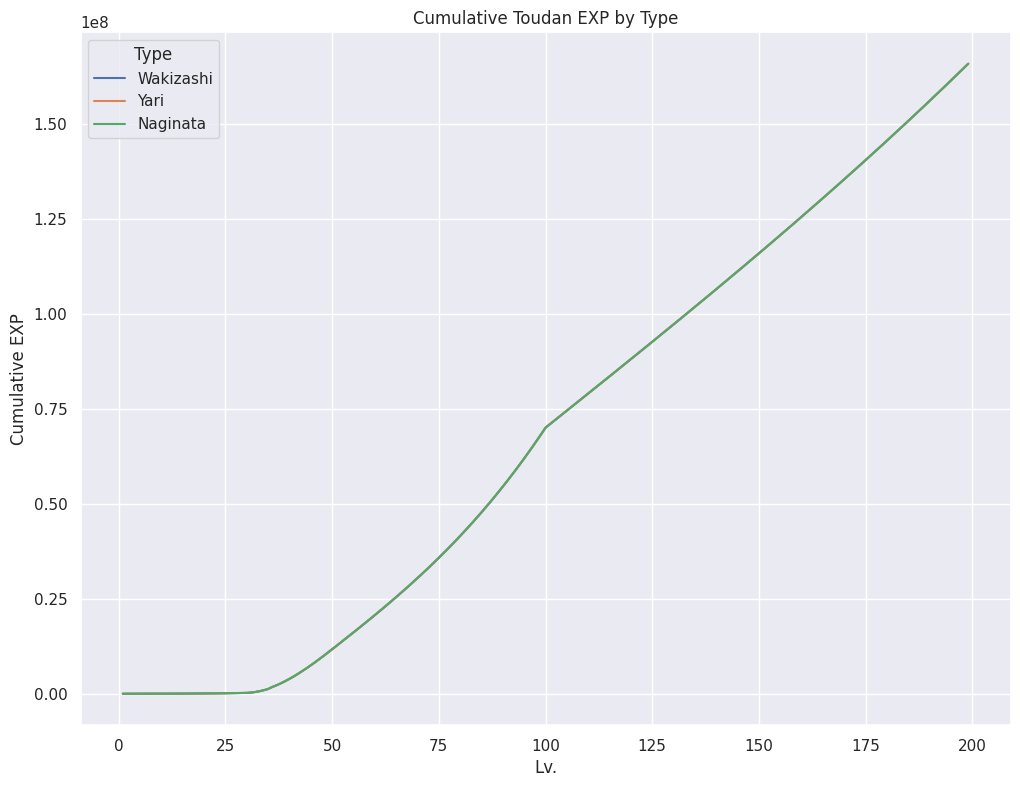

In [110]:
#check if Waki/Yari/Nagi are still the same, yep
plt.figure(figsize = (12, 9))
sns.lineplot(data = df[df['Type'].isin(['Wakizashi','Yari','Naginata'])], x = "Lv.", y = "Cumulative EXP",
             hue = "Type")
plt.title("Cumulative Toudan EXP by Type");

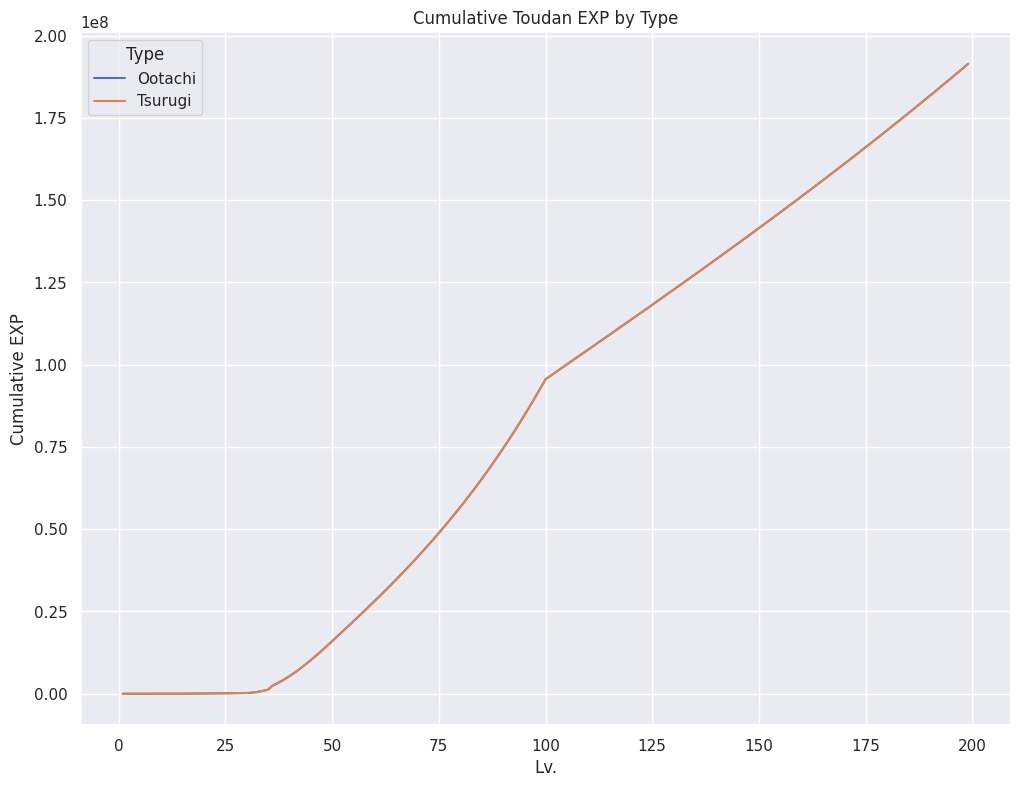

In [112]:
#check if Tsurugi/Ootachi are  the same, yep
plt.figure(figsize = (12, 9))
sns.lineplot(data = df[df['Type'].isin(['Tsurugi', 'Ootachi'])], x = "Lv.", y = "Cumulative EXP",
             hue = "Type")
plt.title("Cumulative Toudan EXP by Type");

In [113]:
# rename sword types for brevity
df["Type"] = df["Type"].map({
    'Ubu' : 'Regular',
    'Tantou' : "Tantouwame",
    'Wakizashi' : "Waki, Yari, Nagiwame",
    'Yari' : "Waki, Yari, Nagiwame",
    'Naginata' : "Waki, Yari, Nagiwame",
    'Uchigatana R3' : "R3 Uchiwame",
    'Uchigatana R4' : "R4 Uchiwame",
    'Tachi' : "Tachiwame",
    'Ootachi': "Ootachi, Tsurugiwame",
    'Tsurugi' : "Ootachi, Tsurugiwame"
})

In [114]:
df["Type"].unique()

array(['Regular', 'Tantouwame', 'Waki, Yari, Nagiwame', 'R3 Uchiwame',
       'Tachiwame', 'Ootachi, Tsurugiwame', 'R4 Uchiwame'], dtype=object)

In [115]:
df = df.drop_duplicates()

In [121]:
df['Type'] = pd.Categorical(df.Type, categories=['Regular', 'Tantouwame', 'Waki, Yari, Nagiwame', 'R3 Uchiwame', 'R4 Uchiwame',
       'Tachiwame', 'Ootachi, Tsurugiwame'], ordered=True)
df = df.sort_values(['Type', 'Lv.']).reset_index(drop = True)

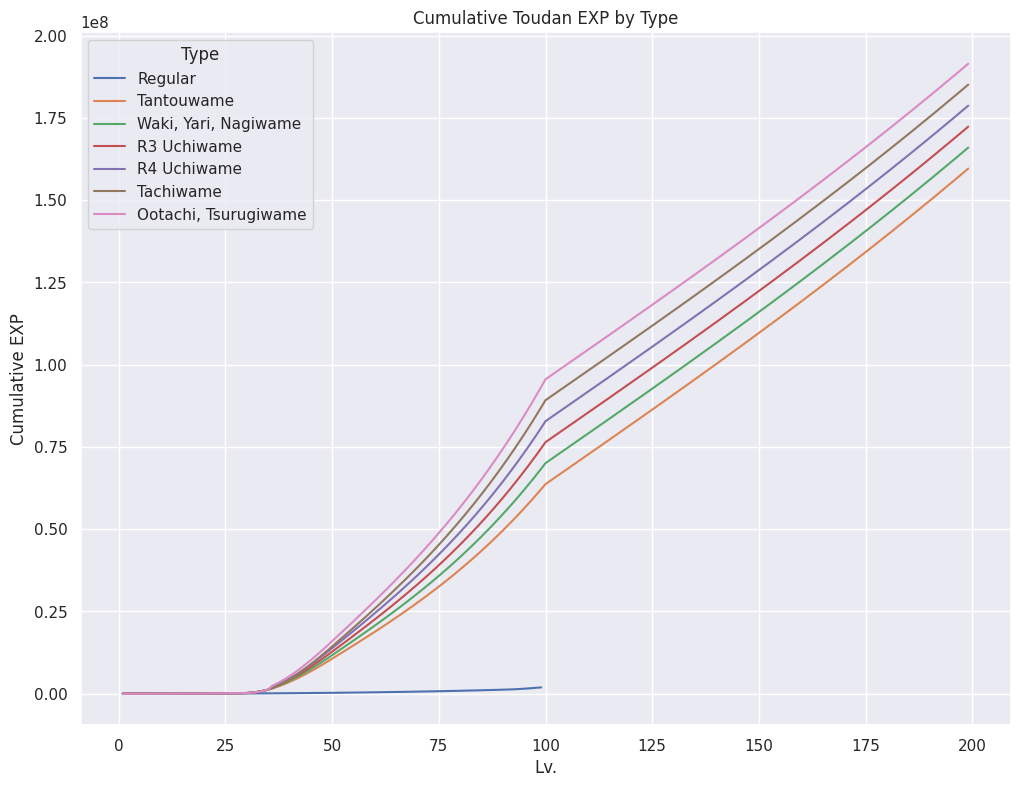

In [122]:
plt.figure(figsize = (12, 9))
sns.lineplot(data = df, x = "Lv.", y = "Cumulative EXP",
             hue = "Type")
plt.title("Cumulative Toudan EXP by Type");

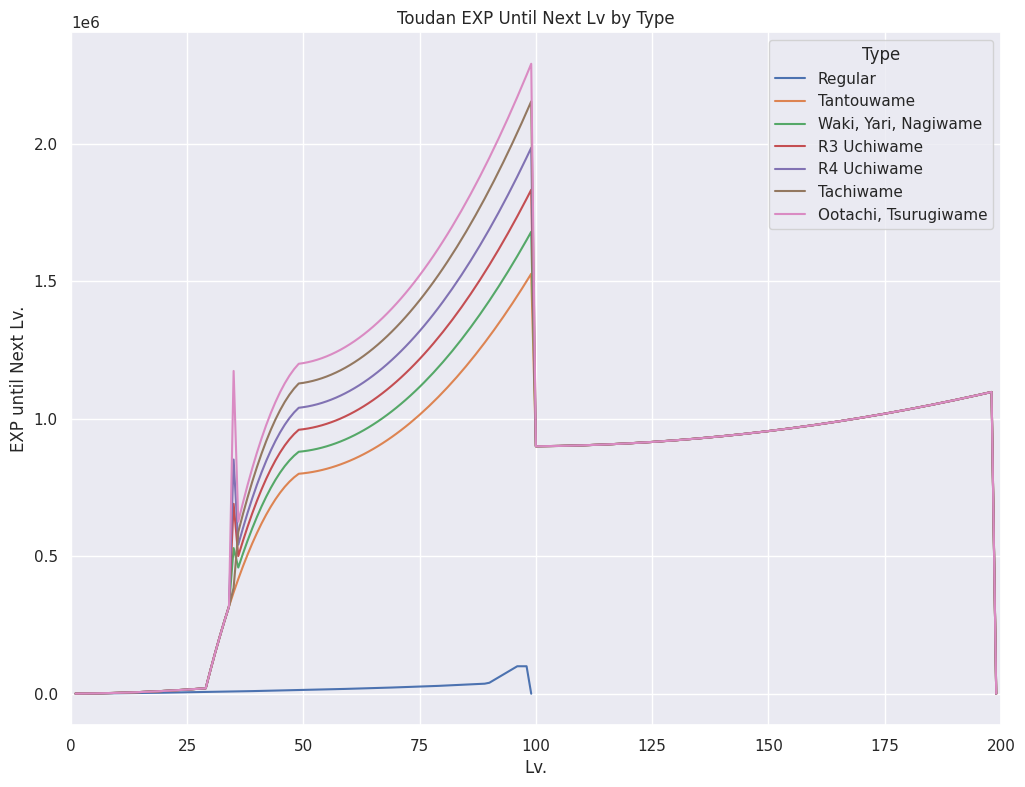

In [123]:
plt.figure(figsize = (12, 9))
sns.lineplot(data = df, x = "Lv.", y = "EXP until Next Lv.",
             hue = "Type")
plt.xlim((0, 200))
plt.title("Toudan EXP Until Next Lv by Type");

In [124]:
# export pandas dataframe as csv for use in calculator
df.to_csv("./tkrb_exp.csv", index = False)

In [125]:
df

,Type,Lv.,Cumulative EXP,EXP until Next Lv.
0,Regular,1,0,100
1,Regular,2,100,200
2,Regular,3,300,400
3,Regular,4,700,600
4,Regular,5,1300,800
...,...,...,...,...
1288,"Ootachi, Tsurugiwame",195,187099706,1086087
1289,"Ootachi, Tsurugiwame",196,188185793,1089870
1290,"Ootachi, Tsurugiwame",197,189275663,1093690
1291,"Ootachi, Tsurugiwame",198,190369353,1097549
